# **Projeto de Graduação em Computação II [2026-Q1]**

Universidade Federal do ABC

Orientador Carlos da Silva dos Santos

### **EQUIPE**

---

Caio Cardoso Dos Santos - RA: 11202021632

Victor Ravazio de Lima - RA: 11201920941

### **IMPLEMENTAÇÃO**
---

In [1]:
# modulo para importar dataset a partir de um link
!pip install gdown

In [2]:
!pip install emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 10.7 MB/s eta 0:00:00


In [3]:
#Bibliotecas
import pandas as pd
import numpy as np
import json
from datetime import datetime
from google.colab import files
import gdown
import matplotlib.pyplot as plt


In [4]:
# baixando dataset para o collab
import gdown

file_id = "1Sqfda0bUD5mrUKSGUFCerUiN1kxeB-Cm"
url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(url, "contas_suspensas.json", quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1Sqfda0bUD5mrUKSGUFCerUiN1kxeB-Cm
From (redirected): https://drive.google.com/uc?id=1Sqfda0bUD5mrUKSGUFCerUiN1kxeB-Cm&confirm=t&uuid=6b1b48a5-03db-4c87-892c-52e048585d54
To: /content/contas_suspensas.json
100%|██████████| 2.59G/2.59G [00:33<00:00, 77.9MB/s]


'contas_suspensas.json'

In [5]:
#obtendo o caminho do dataset
file_path = "contas_suspensas.json"


In [6]:
#importando e manipulando o dataset em json Lines (cada linha deste "json" é um "json")

data = [] #lista de jsons - basicamente um dicionario
with open(file_path, "r", encoding="utf-8") as f:
    for line in f:
        data.append(json.loads(line)) #converte o Json em dicionario e adiciona a lista "data"

In [7]:
#extraindo texto completo
def extract_full_text(tweet_obj):
    # Caso truncado
    if tweet_obj.get("truncated"):
        # Se existe versão completa
        if "extended_tweet" in tweet_obj and "full_text" in tweet_obj["extended_tweet"]:
            return tweet_obj["extended_tweet"]["full_text"]
        else:
            # se for truncado e não existir o "full_text", retorna none
            return None
    else:
        return tweet_obj.get("text", "")

In [8]:
def has_image(tweet_obj):
    # checa o próprio tweet
    if "extended_entities" in tweet_obj:
        media = tweet_obj["extended_entities"].get("media", [])
        if any(m.get("type") == "photo" for m in media):
            return True

    #Resolvendo o "problema" - extended entities pode estar em "extended_tweet" e não no tweet base
    if "extended_tweet" in tweet_obj:
        if "extended_entities" in tweet_obj["extended_tweet"]:
            media = tweet_obj["extended_tweet"]["extended_entities"].get("media", [])
            if any(m.get("type") == "photo" for m in media):
                return True

    # checa quote (se existir)
    if tweet_obj.get("is_quote_status") and "quoted_status" in tweet_obj:
        quoted = tweet_obj["quoted_status"]
        if "extended_entities" in quoted:
            media = quoted["extended_entities"].get("media", [])
            if any(m.get("type") == "photo" for m in media):
                return True

    return False

In [9]:
#Construindo lista estruturada
processed = [] #lista de dicionarios (cada tweet é um dicionario - no fim é facil converter dicionario num df)

for tweet in data: #data é uma lista de dicionarios e tweet itera dicionario em dicionario em data

    # Identificando se é retweet
    if "retweeted_status" in tweet:
        base_tweet = tweet["retweeted_status"] #retweeted_status é um subdicionario dentro do dicionario tweets - contem as infos do retweet como texto, autor e etc
        is_retweet = True

        original_tweet_date = base_tweet.get("created_at")
        retweeter_id = tweet.get("user", {}).get("id_str")
        retweet_date = tweet.get("created_at")

    #Caso contrario, é um tweet original
    else:
        base_tweet = tweet
        is_retweet = False

        original_tweet_date = tweet.get("created_at")
        retweeter_id = None
        retweet_date = None

    #verificando se existe imagem (caso sim, desconsiderar o tweet)
    if has_image(base_tweet):
      continue

    # Tratando quotes (respostas)
    is_quote = base_tweet.get("is_quote_status", False) #verificando se é um quote

    if is_quote and "quoted_status" in base_tweet: #se for quote e o campo quote_status (dicionario de elementos, igual retweet status) não for null
        quoted_tweet = base_tweet["quoted_status"] #quoted_status é um subdicionario dentro do dicionario tweets - contem as infos do quote como texto, autor e etc

        quoted_text = extract_full_text(quoted_tweet)
        quoted_tweet_id = quoted_tweet.get("id_str")
        quoted_user_id = quoted_tweet.get("user", {}).get("id_str")
    else:
        quoted_text = None
        quoted_tweet_id = None
        quoted_user_id = None


    #Tratando reply
    is_reply = base_tweet.get("in_reply_to_status_id", False) is not None

    reply_to_tweet_id = base_tweet.get("in_reply_to_status_id_str")
    reply_to_user_id = base_tweet.get("in_reply_to_user_id_str")
    reply_to_screen_name = base_tweet.get("in_reply_to_screen_name")

    #Produzindo o dicionario do tweet e adicionando na lista
    text = extract_full_text(base_tweet)

    # Se text retorna null, descartar
    if text is None:
      continue

    processed.append({
        "tweet_id": base_tweet.get("id_str"),
        "user_id_original": base_tweet.get("user", {}).get("id_str"),
        "text": text,
        "created_at_original": original_tweet_date,

        "retweet_count": base_tweet.get("retweet_count", 0),
        "like_count": base_tweet.get("favorite_count", 0),

        # retweet info
        "is_retweet": is_retweet,
        "retweeter_user_id": retweeter_id,
        "retweet_created_at": retweet_date,

        # quote info
        "is_quote": is_quote,
        "quoted_tweet_id": quoted_tweet_id,
        "quoted_user_id": quoted_user_id,
        "quoted_text": quoted_text,

        # --- REPLY ---
        "is_reply": is_reply,
        "reply_to_tweet_id": reply_to_tweet_id,
        "reply_to_user_id": reply_to_user_id,
        "reply_to_screen_name": reply_to_screen_name
    })

In [10]:
#Criando DataFrame

df = pd.DataFrame(processed)

df
#print(df.shape)

,tweet_id,user_id_original,text,created_at_original,retweet_count,like_count,is_retweet,retweeter_user_id,retweet_created_at,is_quote,quoted_tweet_id,quoted_user_id,quoted_text,is_reply,reply_to_tweet_id,reply_to_user_id,reply_to_screen_name
0,1286723608866324480,174818242,O bom dessa censura toda é que fica clara a in...,Fri Jul 24 18:03:09 +0000 2020,431,1788,True,1244301656747016194,Fri Jul 24 19:20:09 +0000 2020,False,None,None,None,False,None,None,None
1,1286734747629170688,3092434408,Mude a localização para acessar meus tweets:\n...,Fri Jul 24 18:47:24 +0000 2020,631,1693,True,971597464938704896,Fri Jul 24 19:20:09 +0000 2020,False,None,None,None,False,None,None,None
2,1286713348063666186,1090291692744466433,#URGENTE: Após pedido de Alexandre de Moraes (...,Fri Jul 24 17:22:22 +0000 2020,810,1801,True,3339003100,Fri Jul 24 19:20:09 +0000 2020,False,None,None,None,False,None,None,None
3,1286719270555201537,1196864541726060544,24.07.2020\n\nDia Nacional da Censura do Twitt...,Fri Jul 24 17:45:54 +0000 2020,5,7,True,862362261977006081,Fri Jul 24 19:20:09 +0000 2020,False,None,None,None,False,None,None,None
4,1286740416457572353,2822662924,"Caçaram a conta do Roberto Jefferson, e agora ...",Fri Jul 24 19:09:56 +0000 2020,6,19,True,1284921903250014208,Fri Jul 24 19:20:09 +0000 2020,False,None,None,None,False,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
357589,1287020973653401600,3406756888,"O Ministro do STF, Alexandre Moraes superou to...",Sat Jul 25 13:44:46 +0000 2020,1869,7826,True,1114287189003833344,Sat Jul 25 20:44:05 +0000 2020,False,None,None,None,False,None,None,None
357590,1286742837657296896,27019396,Tive acesso à decisão que calou as contas de T...,Fri Jul 24 19:19:33 +0000 2020,903,2031,True,1187769346535428100,Sat Jul 25 20:44:06 +0000 2020,False,None,None,None,False,None,None,None
357591,1286849095383101441,1022536839398350853,URGENTE: SENADORES impeachment de Alexandre de...,Sat Jul 25 02:21:47 +0000 2020,1727,4429,True,1245641247621918729,Sat Jul 25 20:44:06 +0000 2020,False,None,None,None,False,None,None,None
357592,1286718273577517061,25858078,Vocês também estão sentindo que o clima aqui n...,Fri Jul 24 17:41:57 +0000 2020,899,17572,False,None,None,False,None,None,None,False,None,None,None


In [11]:
# Buscando textos originais dos replys - O texto original (que esta sendo respondido) não está no tweet que esta respondendo: ideia buscar neste dataset pelo id neste dataset
# garantindo ids em strings
df["tweet_id"] = df["tweet_id"].astype(str)
df["reply_to_tweet_id"] = df["reply_to_tweet_id"].astype(str)

# criar dicionário id -> texto
id_to_text = dict(zip(df["tweet_id"], df["text"])) # Organizando o dataset num dicionario: Chave: tweet id, conteudo: texto - isso facilita a busca (ex: ao fornecer a chave X, retorna seu texto Y)

# Criando reply text: Basicamente varre cada reply_tweet_id do df, e se não for none, aplica no dicionario, ou seja, busca no dicionario aquele tweet id do reply como chave - se encontrar, retorna o conteudo, se não, none
df["reply_text"] = df["reply_to_tweet_id"].map(id_to_text)

In [12]:
#Removendo URLs
import re
import emoji

def clean_text(text):
    if not isinstance(text, str):
        return ""

    text = emoji.replace_emoji(text, replace='')
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"RT\s+", "", text)
    text = re.sub(r"\n", " ", text)
    return text.strip()

df["text"] = df["text"].apply(clean_text)
df["quoted_text"] = df["quoted_text"].apply(clean_text)
df["reply_text"] = df["reply_text"].apply(clean_text)

In [13]:
#removendo textos vazios
df = df[df["text"].notnull()]
df = df[df["text"].str.strip() != ""]
print(df.shape)

(357594, 18)


In [14]:
#replys "usáveis" - Antes de remover duplicatas
replys = df.loc[(df["is_reply"] == True) & (df["reply_text"].str.strip() != "")]

In [15]:
replys

,tweet_id,user_id_original,text,created_at_original,retweet_count,like_count,is_retweet,retweeter_user_id,retweet_created_at,is_quote,quoted_tweet_id,quoted_user_id,quoted_text,is_reply,reply_to_tweet_id,reply_to_user_id,reply_to_screen_name,reply_text
18,1286742996982149120,1266828023833276417,Comunista defendendo a censura. Nada de novo p...,Fri Jul 24 19:20:11 +0000 2020,0,0,False,None,None,False,None,None,,True,1286718273577517061,25858078,ManuelaDavila,Vocês também estão sentindo que o clima aqui n...
53,1286743020487016448,1147260805911666689,Mude a localização para acessar meus tweets: 1...,Fri Jul 24 19:20:17 +0000 2020,0,0,False,None,None,False,None,None,,True,1286723012008517632,174818242,leandroruschel,As contas censuradas hoje contam com mais leit...
83,1286741006977818625,971792681293795328,Eu não consigo ler isso sem passar raiva desse...,Fri Jul 24 19:12:17 +0000 2020,2,5,True,754156625896898560,Fri Jul 24 19:20:21 +0000 2020,True,1286723678567366656,357030742,Alexandre determina e Twitter bloqueia perfis ...,True,1286735449306914816,2804949532,GFiuza_Oficial,O tiranete Alexandre de Moraes passou de todos...
92,1286743042100256769,587385641,"Isso é total ditadura!! Mas e o executivo , nã...",Fri Jul 24 19:20:22 +0000 2020,0,0,False,None,None,False,None,None,,True,1286735449306914816,2804949532,GFiuza_Oficial,O tiranete Alexandre de Moraes passou de todos...
102,1286723919211364358,1116451149660467207,"... o PGR, Augusto Aras, já opinou pela conces...",Fri Jul 24 18:04:23 +0000 2020,136,658,True,1027624301170712578,Fri Jul 24 19:20:23 +0000 2020,False,None,None,,True,1286723917822988288,1116451149660467207,ManssurJoao,"Hoje, 24/07, Fakhoury e demais investigados pe..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
357266,1286722521958621185,1253042272939192321,ALERTA: Alexandre De Moraes tem que se afastar...,Fri Jul 24 17:58:50 +0000 2020,33,83,True,49847686,Sat Jul 25 20:41:15 +0000 2020,False,None,None,,True,1286720166701740034,1201864404855377922,JornalBSM,SEXTA-FEIRA DA VERGONHA Alexandre de Moraes ma...
357289,1287087079906848770,52849416,Financiamentos de jatinhos pelo BNDES: - João...,Sat Jul 25 18:07:27 +0000 2020,49,475,True,730503578385842180,Sat Jul 25 20:41:25 +0000 2020,False,None,None,,True,1287080971771301889,52849416,FMouraBrasil,"Luciano Hang faturou em governos Itamar, FHC, ..."
357371,1287117826181013505,33071040,O que vem a seguir? Dificil dizer. Mas minha ...,Sat Jul 25 20:09:37 +0000 2020,24,133,True,919958619889766400,Sat Jul 25 20:42:01 +0000 2020,False,None,None,,True,1287117824436195329,33071040,rmotta2,A principal vítima do covid foi a mídia. A pr...
357442,1287087079906848770,52849416,Financiamentos de jatinhos pelo BNDES: - João...,Sat Jul 25 18:07:27 +0000 2020,50,478,True,1172143046072442880,Sat Jul 25 20:42:43 +0000 2020,False,None,None,,True,1287080971771301889,52849416,FMouraBrasil,"Luciano Hang faturou em governos Itamar, FHC, ..."


In [16]:
#quotes - Antes de remover duplicatas

quotes = df.loc[(df["is_quote"] == True) & (df["quoted_text"].str.strip() != "")]
quotes

,tweet_id,user_id_original,text,created_at_original,retweet_count,like_count,is_retweet,retweeter_user_id,retweet_created_at,is_quote,quoted_tweet_id,quoted_user_id,quoted_text,is_reply,reply_to_tweet_id,reply_to_user_id,reply_to_screen_name,reply_text
23,1286738401211887616,884493009840218114,...E a Democracia aos poucos vai se tornando r...,Fri Jul 24 19:01:55 +0000 2020,9,16,True,1264895757154422785,Fri Jul 24 19:20:12 +0000 2020,True,1286734325120225282,181126821,Corda pra se enforcar! #STFVergonhaNacional #...,False,None,None,None,
28,1286743005395902466,1044567268527681536,#VozParaBernardoKuster #STFVergonhaNacional M...,Fri Jul 24 19:20:13 +0000 2020,0,0,False,None,None,True,1286734747629170688,3092434408,Mude a localização para acessar meus tweets: 1...,False,None,None,None,
33,1286741998469349377,2847072890,"Até quando iremos assistir inertes, atitudes a...",Fri Jul 24 19:16:13 +0000 2020,4,10,True,867389122939420673,Fri Jul 24 19:20:14 +0000 2020,True,1286713348063666186,1090291692744466433,#URGENTE: Após pedido de Alexandre de Moraes (...,False,None,None,None,
62,1286743025696346117,1242987831611531272,"Daqui do EUA, eu sigo o Bernardo! #VozParaBern...",Fri Jul 24 19:20:18 +0000 2020,0,0,False,None,None,True,1094405365494620160,3092434408,Já cancelou sua assinatura na grande mídia hoj...,False,None,None,None,
71,1286726401455005697,162453393,Mas não tenha NENHUMA DÚVIDA disso. Seria um g...,Fri Jul 24 18:14:14 +0000 2020,27,275,True,1258254663683629056,Fri Jul 24 19:20:20 +0000 2020,True,1286723688864391169,2396424942,"Podem ter certeza, se fosse a conta do Nando M...",False,None,None,None,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
357547,1286847092468715527,2804949532,Precisa ser muito cínico e muito covarde p/ cl...,Sat Jul 25 02:13:49 +0000 2020,4758,18938,True,122110444,Sat Jul 25 20:43:41 +0000 2020,True,1286790328809390081,1222939896349970432,Alexandre de Moraes ameaçou aplicar multa diár...,False,None,None,None,
357560,1287126433349931008,1129526345954975745,Tomara que dê certo,Sat Jul 25 20:43:50 +0000 2020,0,0,False,None,None,True,1287110892941959168,15918946,"Por meio de nota pública, membros do MP Pró-So...",False,None,None,None,
357564,1287124071587680256,75465329,Confirmo,Sat Jul 25 20:34:26 +0000 2020,4,6,True,113227999,Sat Jul 25 20:43:51 +0000 2020,True,1287123425312604160,1247602809853394944,Confirmen que ustedes también están esperando ...,False,None,None,None,
357574,1287126460243873793,218276449,A escalada de Hang escancara a triste realidad...,Sat Jul 25 20:43:56 +0000 2020,0,0,False,None,None,True,1287029573272711168,195474607,Exclusivo: Luciano Hang obteve 55 empréstimos ...,False,None,None,None,


In [17]:
#genéricos - Antes de remover duplicatas

generics = df.loc[(df["is_quote"] == False) & (df["is_reply"] == False)]
generics

,tweet_id,user_id_original,text,created_at_original,retweet_count,like_count,is_retweet,retweeter_user_id,retweet_created_at,is_quote,quoted_tweet_id,quoted_user_id,quoted_text,is_reply,reply_to_tweet_id,reply_to_user_id,reply_to_screen_name,reply_text
0,1286723608866324480,174818242,O bom dessa censura toda é que fica clara a in...,Fri Jul 24 18:03:09 +0000 2020,431,1788,True,1244301656747016194,Fri Jul 24 19:20:09 +0000 2020,False,None,None,,False,None,None,None,
1,1286734747629170688,3092434408,Mude a localização para acessar meus tweets: 1...,Fri Jul 24 18:47:24 +0000 2020,631,1693,True,971597464938704896,Fri Jul 24 19:20:09 +0000 2020,False,None,None,,False,None,None,None,
2,1286713348063666186,1090291692744466433,#URGENTE: Após pedido de Alexandre de Moraes (...,Fri Jul 24 17:22:22 +0000 2020,810,1801,True,3339003100,Fri Jul 24 19:20:09 +0000 2020,False,None,None,,False,None,None,None,
3,1286719270555201537,1196864541726060544,24.07.2020 Dia Nacional da Censura do Twitter...,Fri Jul 24 17:45:54 +0000 2020,5,7,True,862362261977006081,Fri Jul 24 19:20:09 +0000 2020,False,None,None,,False,None,None,None,
4,1286740416457572353,2822662924,"Caçaram a conta do Roberto Jefferson, e agora ...",Fri Jul 24 19:09:56 +0000 2020,6,19,True,1284921903250014208,Fri Jul 24 19:20:09 +0000 2020,False,None,None,,False,None,None,None,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
357589,1287020973653401600,3406756888,"O Ministro do STF, Alexandre Moraes superou to...",Sat Jul 25 13:44:46 +0000 2020,1869,7826,True,1114287189003833344,Sat Jul 25 20:44:05 +0000 2020,False,None,None,,False,None,None,None,
357590,1286742837657296896,27019396,Tive acesso à decisão que calou as contas de T...,Fri Jul 24 19:19:33 +0000 2020,903,2031,True,1187769346535428100,Sat Jul 25 20:44:06 +0000 2020,False,None,None,,False,None,None,None,
357591,1286849095383101441,1022536839398350853,URGENTE: SENADORES impeachment de Alexandre de...,Sat Jul 25 02:21:47 +0000 2020,1727,4429,True,1245641247621918729,Sat Jul 25 20:44:06 +0000 2020,False,None,None,,False,None,None,None,
357592,1286718273577517061,25858078,Vocês também estão sentindo que o clima aqui n...,Fri Jul 24 17:41:57 +0000 2020,899,17572,False,None,None,False,None,None,,False,None,None,None,


In [18]:
#tamanho do df
num_tweets = len(df)
print(f"O DataFrame contém {num_tweets} tweets no total.")

O DataFrame contém 357594 tweets no total.


In [19]:
#quantidade de retweets
num_rt = df[df['is_retweet'] == True].shape[0]
print(f"O DataFrame contém {num_rt} retweets.")

O DataFrame contém 301604 retweets.


In [20]:
#quantidade de Tweets originais (não são retweets)
num_tweets_or = df[df['is_retweet'] == False].shape[0]
print(f"O DataFrame contém {num_tweets_or} tweets originais (tweets que não são retweets).")

O DataFrame contém 55990 tweets originais (tweets que não são retweets).


In [21]:
#Quantidade de duplicatas
df_copy = df.copy()
duplicados = df_copy[df_copy.duplicated(subset='text', keep='first')]
duplicados

,tweet_id,user_id_original,text,created_at_original,retweet_count,like_count,is_retweet,retweeter_user_id,retweet_created_at,is_quote,quoted_tweet_id,quoted_user_id,quoted_text,is_reply,reply_to_tweet_id,reply_to_user_id,reply_to_screen_name,reply_text
13,1286734747629170688,3092434408,Mude a localização para acessar meus tweets: 1...,Fri Jul 24 18:47:24 +0000 2020,632,1692,True,3084031535,Fri Jul 24 19:20:11 +0000 2020,False,None,None,,False,None,None,None,
25,1286735449306914816,2804949532,O tiranete Alexandre de Moraes passou de todos...,Fri Jul 24 18:50:12 +0000 2020,2644,7311,True,1273773223864422401,Fri Jul 24 19:20:12 +0000 2020,False,None,None,,False,None,None,None,
30,1286720166701740034,1201864404855377922,SEXTA-FEIRA DA VERGONHA Alexandre de Moraes ma...,Fri Jul 24 17:49:28 +0000 2020,1804,4530,True,2244082160,Fri Jul 24 19:20:13 +0000 2020,False,None,None,,False,None,None,None,
43,1286735449306914816,2804949532,O tiranete Alexandre de Moraes passou de todos...,Fri Jul 24 18:50:12 +0000 2020,2645,7318,True,37895191,Fri Jul 24 19:20:15 +0000 2020,False,None,None,,False,None,None,None,
44,1286734747629170688,3092434408,Mude a localização para acessar meus tweets: 1...,Fri Jul 24 18:47:24 +0000 2020,633,1694,True,896798082033217538,Fri Jul 24 19:20:15 +0000 2020,False,None,None,,False,None,None,None,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
357587,1286735449306914816,2804949532,O tiranete Alexandre de Moraes passou de todos...,Fri Jul 24 18:50:12 +0000 2020,15609,52897,True,1190701569165201410,Sat Jul 25 20:44:04 +0000 2020,False,None,None,,False,None,None,None,
357588,1287055276013694977,472033751,#BOBJEFF Vou combinar com vocês que me seguem ...,Sat Jul 25 16:01:04 +0000 2020,1848,7265,True,1034955859741356033,Sat Jul 25 20:44:04 +0000 2020,False,None,None,,False,None,None,None,
357589,1287020973653401600,3406756888,"O Ministro do STF, Alexandre Moraes superou to...",Sat Jul 25 13:44:46 +0000 2020,1869,7826,True,1114287189003833344,Sat Jul 25 20:44:05 +0000 2020,False,None,None,,False,None,None,None,
357590,1286742837657296896,27019396,Tive acesso à decisão que calou as contas de T...,Fri Jul 24 19:19:33 +0000 2020,903,2031,True,1187769346535428100,Sat Jul 25 20:44:06 +0000 2020,False,None,None,,False,None,None,None,


In [22]:
#tweets originais duplicados
orig_dup = duplicados[duplicados['is_retweet'] == False]
orig_dup

,tweet_id,user_id_original,text,created_at_original,retweet_count,like_count,is_retweet,retweeter_user_id,retweet_created_at,is_quote,quoted_tweet_id,quoted_user_id,quoted_text,is_reply,reply_to_tweet_id,reply_to_user_id,reply_to_screen_name,reply_text
53,1286743020487016448,1147260805911666689,Mude a localização para acessar meus tweets: 1...,Fri Jul 24 19:20:17 +0000 2020,0,0,False,None,None,False,None,None,,True,1286723012008517632,174818242,leandroruschel,As contas censuradas hoje contam com mais leit...
355,1286743178142527488,984467430876549120,"Qual será o teor do ""textão"" que os Generais d...",Fri Jul 24 19:20:54 +0000 2020,0,0,False,None,None,False,None,None,,True,1286735449306914816,2804949532,GFiuza_Oficial,O tiranete Alexandre de Moraes passou de todos...
363,1286743185021120517,1236816094985433089,Mude a localização para acessar meus tweets: 1...,Fri Jul 24 19:20:56 +0000 2020,0,0,False,None,None,False,None,None,,True,1286723174231617536,166449545,Edgard_Piccoli,
513,1286743269653852161,2232466590,Quem apoia a censura é ditador e fascista! Qu...,Fri Jul 24 19:21:16 +0000 2020,0,0,False,None,None,False,None,None,,True,1286726401455005697,162453393,aguedescartoon,Mas não tenha NENHUMA DÚVIDA disso. Seria um g...
620,1286743320467836929,2232466590,Quem apoia a censura é ditador e fascista! Qu...,Fri Jul 24 19:21:28 +0000 2020,0,0,False,None,None,False,None,None,,True,1286728510573338630,33372675,macdebochado,"Roberto Jefferson, Luciano Hang, Allan dos San..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
357341,1287125923737874432,1265039279169863681,A CENSURA DO MINISTRO ALEXANDRE DE MORAES CO...,Sat Jul 25 20:41:48 +0000 2020,0,0,False,None,None,False,None,None,,False,None,None,None,
357395,1287126019636420621,2319973086,Roberto Jefferson fala sobre censura imposta p...,Sat Jul 25 20:42:11 +0000 2020,0,0,False,None,None,False,None,None,,False,None,None,None,
357401,1287126039114719237,1259210503395725315,#STFNaoVaiNosCalar nunca,Sat Jul 25 20:42:16 +0000 2020,0,0,False,None,None,True,1287055276013694977,472033751,#BOBJEFF Vou combinar com vocês que me seguem ...,False,None,None,None,
357429,1287126099911217152,1359815930,##FreedomOfSpeech Senta o dedo robozada Retwit...,Sat Jul 25 20:42:30 +0000 2020,0,0,False,None,None,True,1286840830603464704,1187347199535001600,Guilherme Fiuza: “Ou os democratas reagem agor...,False,None,None,None,


In [23]:
#numero liquido de tweets
num_liq = num_tweets - len(duplicados)
print(f"O DataFrame contém {num_liq} tweets usáveis.")

O DataFrame contém 51521 tweets usáveis.


In [24]:
#verificando retweets iguais
retweets = df.loc[df['is_retweet'] == True].copy()

retweets_iguais = retweets[retweets.duplicated(subset='text', keep='first')]

retweets_iguais

,tweet_id,user_id_original,text,created_at_original,retweet_count,like_count,is_retweet,retweeter_user_id,retweet_created_at,is_quote,quoted_tweet_id,quoted_user_id,quoted_text,is_reply,reply_to_tweet_id,reply_to_user_id,reply_to_screen_name,reply_text
13,1286734747629170688,3092434408,Mude a localização para acessar meus tweets: 1...,Fri Jul 24 18:47:24 +0000 2020,632,1692,True,3084031535,Fri Jul 24 19:20:11 +0000 2020,False,None,None,,False,None,None,None,
25,1286735449306914816,2804949532,O tiranete Alexandre de Moraes passou de todos...,Fri Jul 24 18:50:12 +0000 2020,2644,7311,True,1273773223864422401,Fri Jul 24 19:20:12 +0000 2020,False,None,None,,False,None,None,None,
30,1286720166701740034,1201864404855377922,SEXTA-FEIRA DA VERGONHA Alexandre de Moraes ma...,Fri Jul 24 17:49:28 +0000 2020,1804,4530,True,2244082160,Fri Jul 24 19:20:13 +0000 2020,False,None,None,,False,None,None,None,
43,1286735449306914816,2804949532,O tiranete Alexandre de Moraes passou de todos...,Fri Jul 24 18:50:12 +0000 2020,2645,7318,True,37895191,Fri Jul 24 19:20:15 +0000 2020,False,None,None,,False,None,None,None,
44,1286734747629170688,3092434408,Mude a localização para acessar meus tweets: 1...,Fri Jul 24 18:47:24 +0000 2020,633,1694,True,896798082033217538,Fri Jul 24 19:20:15 +0000 2020,False,None,None,,False,None,None,None,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
357587,1286735449306914816,2804949532,O tiranete Alexandre de Moraes passou de todos...,Fri Jul 24 18:50:12 +0000 2020,15609,52897,True,1190701569165201410,Sat Jul 25 20:44:04 +0000 2020,False,None,None,,False,None,None,None,
357588,1287055276013694977,472033751,#BOBJEFF Vou combinar com vocês que me seguem ...,Sat Jul 25 16:01:04 +0000 2020,1848,7265,True,1034955859741356033,Sat Jul 25 20:44:04 +0000 2020,False,None,None,,False,None,None,None,
357589,1287020973653401600,3406756888,"O Ministro do STF, Alexandre Moraes superou to...",Sat Jul 25 13:44:46 +0000 2020,1869,7826,True,1114287189003833344,Sat Jul 25 20:44:05 +0000 2020,False,None,None,,False,None,None,None,
357590,1286742837657296896,27019396,Tive acesso à decisão que calou as contas de T...,Fri Jul 24 19:19:33 +0000 2020,903,2031,True,1187769346535428100,Sat Jul 25 20:44:06 +0000 2020,False,None,None,,False,None,None,None,


In [25]:
contagem_df = retweets_iguais['text'].value_counts().reset_index()
contagem_df

,text,count
0,O tiranete Alexandre de Moraes passou de todos...,12171
1,Não há como aceitar a censura. Não há como ace...,11950
2,Amigos aqui é Roberto Jefferson. Entrei na con...,8814
3,Urge pautarmos e exigirmos de nossos senadores...,5005
4,Precisa ser muito cínico e muito covarde p/ cl...,4468
...,...,...
4848,Vídeo sobre Liberdade de Expressão. Falo sobre...,1
4849,"Na União Soviética, quem falava o que pensava ...",1
4850,A liberdade foi enterrada viva e com a boca ta...,1
4851,"Gente, acabei de trocar nome e foto em solidar...",1


In [26]:
num_copias = int(contagem_df["count"].sum())
num_copias

291877

In [27]:
#removendo duplicatas
df = df.drop_duplicates(subset=["text"])
print(df.shape)

(51521, 18)


In [28]:
df

,tweet_id,user_id_original,text,created_at_original,retweet_count,like_count,is_retweet,retweeter_user_id,retweet_created_at,is_quote,quoted_tweet_id,quoted_user_id,quoted_text,is_reply,reply_to_tweet_id,reply_to_user_id,reply_to_screen_name,reply_text
0,1286723608866324480,174818242,O bom dessa censura toda é que fica clara a in...,Fri Jul 24 18:03:09 +0000 2020,431,1788,True,1244301656747016194,Fri Jul 24 19:20:09 +0000 2020,False,None,None,,False,None,None,None,
1,1286734747629170688,3092434408,Mude a localização para acessar meus tweets: 1...,Fri Jul 24 18:47:24 +0000 2020,631,1693,True,971597464938704896,Fri Jul 24 19:20:09 +0000 2020,False,None,None,,False,None,None,None,
2,1286713348063666186,1090291692744466433,#URGENTE: Após pedido de Alexandre de Moraes (...,Fri Jul 24 17:22:22 +0000 2020,810,1801,True,3339003100,Fri Jul 24 19:20:09 +0000 2020,False,None,None,,False,None,None,None,
3,1286719270555201537,1196864541726060544,24.07.2020 Dia Nacional da Censura do Twitter...,Fri Jul 24 17:45:54 +0000 2020,5,7,True,862362261977006081,Fri Jul 24 19:20:09 +0000 2020,False,None,None,,False,None,None,None,
4,1286740416457572353,2822662924,"Caçaram a conta do Roberto Jefferson, e agora ...",Fri Jul 24 19:09:56 +0000 2020,6,19,True,1284921903250014208,Fri Jul 24 19:20:09 +0000 2020,False,None,None,,False,None,None,None,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
357574,1287126460243873793,218276449,A escalada de Hang escancara a triste realidad...,Sat Jul 25 20:43:56 +0000 2020,0,0,False,None,None,True,1287029573272711168,195474607,Exclusivo: Luciano Hang obteve 55 empréstimos ...,False,None,None,None,
357582,1287126481282510848,1265039279169863681,A CENSURA DO MINISTRO ALEXANDRE DE MORAES CONT...,Sat Jul 25 20:44:01 +0000 2020,0,0,False,None,None,False,None,None,,False,None,None,None,
357584,1287126483916468232,177756468,O que Alexandre de Moraes fez passa ao largo d...,Sat Jul 25 20:44:02 +0000 2020,0,0,False,None,None,False,None,None,,False,None,None,None,
357592,1286718273577517061,25858078,Vocês também estão sentindo que o clima aqui n...,Fri Jul 24 17:41:57 +0000 2020,899,17572,False,None,None,False,None,None,,False,None,None,None,


In [29]:
print(df.shape)


(51521, 18)


In [30]:
df = df[df["text"].notnull()]

In [31]:
tweet = df.iloc[14]['text']
tweet

'SEXTA-FEIRA DA VERGONHA Alexandre de Moraes manda censurar perfis do jornalista Bernardo Küster (diretor do BSM) e vários outros conservadores. É a mais vasta operação de censura já vista na internet brasileira. #VozParaBernardoKuster'

In [32]:
#replys "usáveis" - depois de remover duplicatas
replys = df.loc[(df["is_reply"] == True) & (df["reply_text"].str.strip() != "")]
replys

,tweet_id,user_id_original,text,created_at_original,retweet_count,like_count,is_retweet,retweeter_user_id,retweet_created_at,is_quote,quoted_tweet_id,quoted_user_id,quoted_text,is_reply,reply_to_tweet_id,reply_to_user_id,reply_to_screen_name,reply_text
18,1286742996982149120,1266828023833276417,Comunista defendendo a censura. Nada de novo p...,Fri Jul 24 19:20:11 +0000 2020,0,0,False,None,None,False,None,None,,True,1286718273577517061,25858078,ManuelaDavila,Vocês também estão sentindo que o clima aqui n...
83,1286741006977818625,971792681293795328,Eu não consigo ler isso sem passar raiva desse...,Fri Jul 24 19:12:17 +0000 2020,2,5,True,754156625896898560,Fri Jul 24 19:20:21 +0000 2020,True,1286723678567366656,357030742,Alexandre determina e Twitter bloqueia perfis ...,True,1286735449306914816,2804949532,GFiuza_Oficial,O tiranete Alexandre de Moraes passou de todos...
92,1286743042100256769,587385641,"Isso é total ditadura!! Mas e o executivo , nã...",Fri Jul 24 19:20:22 +0000 2020,0,0,False,None,None,False,None,None,,True,1286735449306914816,2804949532,GFiuza_Oficial,O tiranete Alexandre de Moraes passou de todos...
102,1286723919211364358,1116451149660467207,"... o PGR, Augusto Aras, já opinou pela conces...",Fri Jul 24 18:04:23 +0000 2020,136,658,True,1027624301170712578,Fri Jul 24 19:20:23 +0000 2020,False,None,None,,True,1286723917822988288,1116451149660467207,ManssurJoao,"Hoje, 24/07, Fakhoury e demais investigados pe..."
106,1286743048148389888,283272318,"Dessa vez a culpa não foi do Twitter, e sim do...",Fri Jul 24 19:20:23 +0000 2020,0,0,False,None,None,False,None,None,,True,1286710967028637702,1055709648043552768,jc38_oliver,É verdade que o Twitter derrubou várias contas...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
356855,1287124827824889858,1069873580442353664,"Estamos de saco cheio de falar, escrever e não...",Sat Jul 25 20:37:27 +0000 2020,0,0,False,None,None,False,None,None,,True,1287120582203645955,472033751,crisbrasilreal,#BOBJEFF Temos que lutar para que a luz da de...
356900,1287124931055161345,1250161817072132098,Acabei de receber um aviso do twitter relatand...,Sat Jul 25 20:37:51 +0000 2020,0,0,False,None,None,False,None,None,,True,1286774651704807424,1184178787786936320,luislacombereal,Não há como aceitar a censura. Não há como ace...
356914,1287124957395394561,40484588,"Censura relativa, ele fez questão de dizer e f...",Sat Jul 25 20:37:58 +0000 2020,0,0,False,None,None,False,None,None,,True,1287120503921152001,99618827,RodrigoGiacomet,LAMENTÁVEL ! Postura ditatorial e autoritária ...
357011,1287125204234203136,250659299,"Esse Lulu boquinha de veludo é uma piada, a f...",Sat Jul 25 20:38:56 +0000 2020,0,0,False,None,None,False,None,None,,True,1287074279260147713,1187347199535001600,PATRIOTASBR38,Quanto você pensa que os ministros do STF não ...


In [33]:
#quotes - depois de remover duplicatas

quotes = df.loc[(df["is_quote"] == True) & (df["quoted_text"].str.strip() != "")]
quotes

,tweet_id,user_id_original,text,created_at_original,retweet_count,like_count,is_retweet,retweeter_user_id,retweet_created_at,is_quote,quoted_tweet_id,quoted_user_id,quoted_text,is_reply,reply_to_tweet_id,reply_to_user_id,reply_to_screen_name,reply_text
23,1286738401211887616,884493009840218114,...E a Democracia aos poucos vai se tornando r...,Fri Jul 24 19:01:55 +0000 2020,9,16,True,1264895757154422785,Fri Jul 24 19:20:12 +0000 2020,True,1286734325120225282,181126821,Corda pra se enforcar! #STFVergonhaNacional #...,False,None,None,None,
28,1286743005395902466,1044567268527681536,#VozParaBernardoKuster #STFVergonhaNacional M...,Fri Jul 24 19:20:13 +0000 2020,0,0,False,None,None,True,1286734747629170688,3092434408,Mude a localização para acessar meus tweets: 1...,False,None,None,None,
33,1286741998469349377,2847072890,"Até quando iremos assistir inertes, atitudes a...",Fri Jul 24 19:16:13 +0000 2020,4,10,True,867389122939420673,Fri Jul 24 19:20:14 +0000 2020,True,1286713348063666186,1090291692744466433,#URGENTE: Após pedido de Alexandre de Moraes (...,False,None,None,None,
62,1286743025696346117,1242987831611531272,"Daqui do EUA, eu sigo o Bernardo! #VozParaBern...",Fri Jul 24 19:20:18 +0000 2020,0,0,False,None,None,True,1094405365494620160,3092434408,Já cancelou sua assinatura na grande mídia hoj...,False,None,None,None,
71,1286726401455005697,162453393,Mas não tenha NENHUMA DÚVIDA disso. Seria um g...,Fri Jul 24 18:14:14 +0000 2020,27,275,True,1258254663683629056,Fri Jul 24 19:20:20 +0000 2020,True,1286723688864391169,2396424942,"Podem ter certeza, se fosse a conta do Nando M...",False,None,None,None,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
357512,1287126326206398465,21189671,"Não se fala mais em caixa preta do BNDES, né?",Sat Jul 25 20:43:24 +0000 2020,0,0,False,None,None,True,1287029573272711168,195474607,Exclusivo: Luciano Hang obteve 55 empréstimos ...,False,None,None,None,
357513,1287126327737360385,958139679810969601,"E se nada for feito, é daí para pior.",Sat Jul 25 20:43:24 +0000 2020,0,0,False,None,None,True,1286794396088913920,979390034351742976,A liberdade de expressão no Brasil está no cor...,False,None,None,None,
357532,1287126350948597760,1117786210766938114,O estado mínimo que o papagaio quer é só para ...,Sat Jul 25 20:43:30 +0000 2020,0,0,False,None,None,True,1287029573272711168,195474607,Exclusivo: Luciano Hang obteve 55 empréstimos ...,False,None,None,None,
357560,1287126433349931008,1129526345954975745,Tomara que dê certo,Sat Jul 25 20:43:50 +0000 2020,0,0,False,None,None,True,1287110892941959168,15918946,"Por meio de nota pública, membros do MP Pró-So...",False,None,None,None,


In [34]:
#genéricos - Depois de remover duplicatas

generics = df.loc[(df["is_quote"] == False) & (df["is_reply"] == False)]
generics

,tweet_id,user_id_original,text,created_at_original,retweet_count,like_count,is_retweet,retweeter_user_id,retweet_created_at,is_quote,quoted_tweet_id,quoted_user_id,quoted_text,is_reply,reply_to_tweet_id,reply_to_user_id,reply_to_screen_name,reply_text
0,1286723608866324480,174818242,O bom dessa censura toda é que fica clara a in...,Fri Jul 24 18:03:09 +0000 2020,431,1788,True,1244301656747016194,Fri Jul 24 19:20:09 +0000 2020,False,None,None,,False,None,None,None,
1,1286734747629170688,3092434408,Mude a localização para acessar meus tweets: 1...,Fri Jul 24 18:47:24 +0000 2020,631,1693,True,971597464938704896,Fri Jul 24 19:20:09 +0000 2020,False,None,None,,False,None,None,None,
2,1286713348063666186,1090291692744466433,#URGENTE: Após pedido de Alexandre de Moraes (...,Fri Jul 24 17:22:22 +0000 2020,810,1801,True,3339003100,Fri Jul 24 19:20:09 +0000 2020,False,None,None,,False,None,None,None,
3,1286719270555201537,1196864541726060544,24.07.2020 Dia Nacional da Censura do Twitter...,Fri Jul 24 17:45:54 +0000 2020,5,7,True,862362261977006081,Fri Jul 24 19:20:09 +0000 2020,False,None,None,,False,None,None,None,
4,1286740416457572353,2822662924,"Caçaram a conta do Roberto Jefferson, e agora ...",Fri Jul 24 19:09:56 +0000 2020,6,19,True,1284921903250014208,Fri Jul 24 19:20:09 +0000 2020,False,None,None,,False,None,None,None,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
357571,1287126455516909570,1609283827,Um dia o capitão deles menospreza a entidade f...,Sat Jul 25 20:43:55 +0000 2020,0,0,False,None,None,False,None,None,,False,None,None,None,
357582,1287126481282510848,1265039279169863681,A CENSURA DO MINISTRO ALEXANDRE DE MORAES CONT...,Sat Jul 25 20:44:01 +0000 2020,0,0,False,None,None,False,None,None,,False,None,None,None,
357584,1287126483916468232,177756468,O que Alexandre de Moraes fez passa ao largo d...,Sat Jul 25 20:44:02 +0000 2020,0,0,False,None,None,False,None,None,,False,None,None,None,
357592,1286718273577517061,25858078,Vocês também estão sentindo que o clima aqui n...,Fri Jul 24 17:41:57 +0000 2020,899,17572,False,None,None,False,None,None,,False,None,None,None,


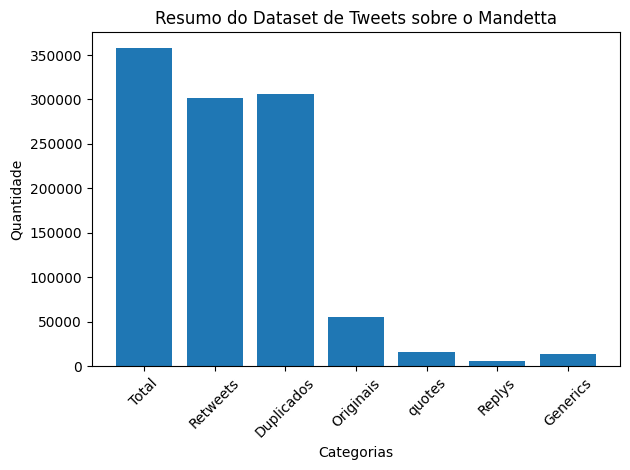

In [35]:
#Grafico resumindo:
total = num_tweets
retweets = num_rt
originais = num_tweets_or
duplicados_qtd = len(duplicados)
num_quotes = len(quotes)
num_replys = len(replys)
num_generics = len(generics)

labels = ["Total", "Retweets",  "Duplicados", "Originais", "quotes","Replys", "Generics"]
values = [total, retweets, duplicados_qtd, originais, num_quotes, num_replys, num_generics]

plt.figure()
plt.bar(labels, values)
plt.title("Resumo do Dataset de Tweets sobre o Mandetta")
plt.xlabel("Categorias")
plt.ylabel("Quantidade")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [36]:
#definindo classes de tweets - 0 Generics, 1 replys, 2 quotes

def classification (tweet_bas):
  #tweet generico (is_reply e is_quote = false)
    if (tweet_bas['is_reply'] == False) & (tweet_bas["is_quote"] == False):
      return 0
  #tweet reply (is_reply = True e is_quote = False)
    elif (tweet_bas['is_reply'] == True) & (tweet_bas["is_quote"] == False):
      return 1
  #Caso contrario é quote (sobreposição de reply e quote é quote, considerado aqui)
    else:
      return 2
df["class"] = df.apply(classification, axis = 1) #normalmente 'aply' opera numa coluna inteiro (axis = 0). Para pegar todas, axis = 1

In [37]:
df

,tweet_id,user_id_original,text,created_at_original,retweet_count,like_count,is_retweet,retweeter_user_id,retweet_created_at,is_quote,quoted_tweet_id,quoted_user_id,quoted_text,is_reply,reply_to_tweet_id,reply_to_user_id,reply_to_screen_name,reply_text,class
0,1286723608866324480,174818242,O bom dessa censura toda é que fica clara a in...,Fri Jul 24 18:03:09 +0000 2020,431,1788,True,1244301656747016194,Fri Jul 24 19:20:09 +0000 2020,False,None,None,,False,None,None,None,,0
1,1286734747629170688,3092434408,Mude a localização para acessar meus tweets: 1...,Fri Jul 24 18:47:24 +0000 2020,631,1693,True,971597464938704896,Fri Jul 24 19:20:09 +0000 2020,False,None,None,,False,None,None,None,,0
2,1286713348063666186,1090291692744466433,#URGENTE: Após pedido de Alexandre de Moraes (...,Fri Jul 24 17:22:22 +0000 2020,810,1801,True,3339003100,Fri Jul 24 19:20:09 +0000 2020,False,None,None,,False,None,None,None,,0
3,1286719270555201537,1196864541726060544,24.07.2020 Dia Nacional da Censura do Twitter...,Fri Jul 24 17:45:54 +0000 2020,5,7,True,862362261977006081,Fri Jul 24 19:20:09 +0000 2020,False,None,None,,False,None,None,None,,0
4,1286740416457572353,2822662924,"Caçaram a conta do Roberto Jefferson, e agora ...",Fri Jul 24 19:09:56 +0000 2020,6,19,True,1284921903250014208,Fri Jul 24 19:20:09 +0000 2020,False,None,None,,False,None,None,None,,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
357574,1287126460243873793,218276449,A escalada de Hang escancara a triste realidad...,Sat Jul 25 20:43:56 +0000 2020,0,0,False,None,None,True,1287029573272711168,195474607,Exclusivo: Luciano Hang obteve 55 empréstimos ...,False,None,None,None,,2
357582,1287126481282510848,1265039279169863681,A CENSURA DO MINISTRO ALEXANDRE DE MORAES CONT...,Sat Jul 25 20:44:01 +0000 2020,0,0,False,None,None,False,None,None,,False,None,None,None,,0
357584,1287126483916468232,177756468,O que Alexandre de Moraes fez passa ao largo d...,Sat Jul 25 20:44:02 +0000 2020,0,0,False,None,None,False,None,None,,False,None,None,None,,0
357592,1286718273577517061,25858078,Vocês também estão sentindo que o clima aqui n...,Fri Jul 24 17:41:57 +0000 2020,899,17572,False,None,None,False,None,None,,False,None,None,None,,0


In [38]:
df[df['tweet_id'].str.contains('1250533884296601603', na=False)]

,tweet_id,user_id_original,text,created_at_original,retweet_count,like_count,is_retweet,retweeter_user_id,retweet_created_at,is_quote,quoted_tweet_id,quoted_user_id,quoted_text,is_reply,reply_to_tweet_id,reply_to_user_id,reply_to_screen_name,reply_text,class


In [39]:
df[df['quoted_text'].str.contains('A maioria esmagadora dos brasileiros é contrária à demissão de Mandetta: 76,2% dos entrevistados discordam do afast', na=False)]

,tweet_id,user_id_original,text,created_at_original,retweet_count,like_count,is_retweet,retweeter_user_id,retweet_created_at,is_quote,quoted_tweet_id,quoted_user_id,quoted_text,is_reply,reply_to_tweet_id,reply_to_user_id,reply_to_screen_name,reply_text,class


In [40]:
#classe 0
sum_class_0 = int ((df['class'] == 0).sum())
sum_class_0


14429

In [41]:
#Classe 1
sum_class_1 = int ((df['class'] == 1).sum())
sum_class_1

20856

In [42]:
#classe 2
sum_class_2 = int ((df['class'] == 2).sum())
sum_class_2

16236

In [43]:
#convertendo para csv
df.to_csv("contas_suspensas.csv", index=False, encoding="utf-8")
files.download("contas_suspensas.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>